In [57]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

plt.style.use("default")

In [58]:
BASE_DIR = Path.cwd().parent

DB_PATH = (
    BASE_DIR
    / "data"
    / "db"
    / "bluestock_mf.db"
)

engine = create_engine(
    f"sqlite:///{DB_PATH}"
)

print(DB_PATH)

c:\Users\lambd\Desktop\BlueStock_project\bluestock_mf_capstone\data\db\bluestock_mf.db


In [59]:
funds = pd.read_sql(
    "SELECT * FROM dim_fund",
    engine
)

nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    engine
)

performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    engine
)

transactions = pd.read_sql(
    "SELECT * FROM fact_transactions",
    engine
)

In [60]:
print(funds.shape)
print(nav.shape)
print(performance.shape)
print(transactions.shape)

(40, 8)
(64320, 3)
(40, 7)
(32778, 6)


Chart 1 — Category Distribution

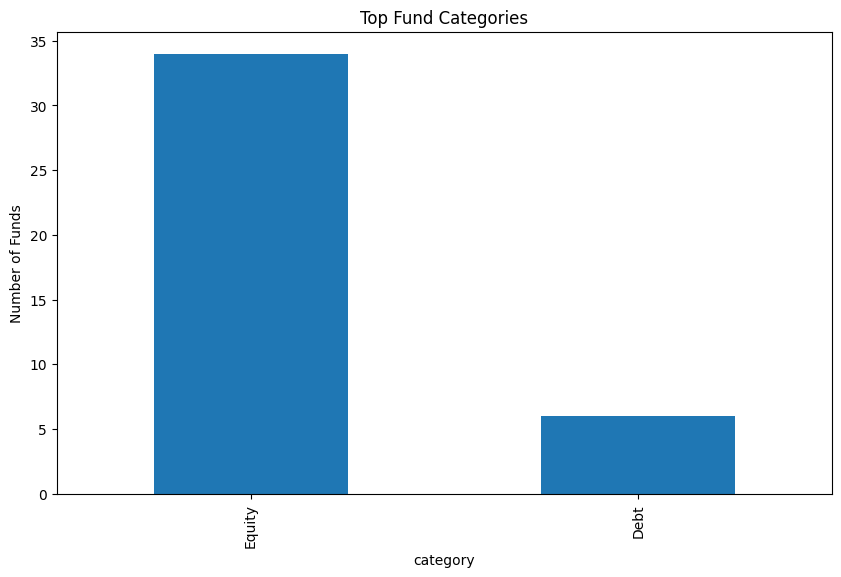

In [61]:
category_counts = (
    funds["category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Top Fund Categories"
)

plt.ylabel(
    "Number of Funds"
)

plt.show()

### Insight

Equity-oriented categories dominate the fund universe,
indicating higher investor preference for growth-oriented products.

Chart 2 — Fund House Distribution

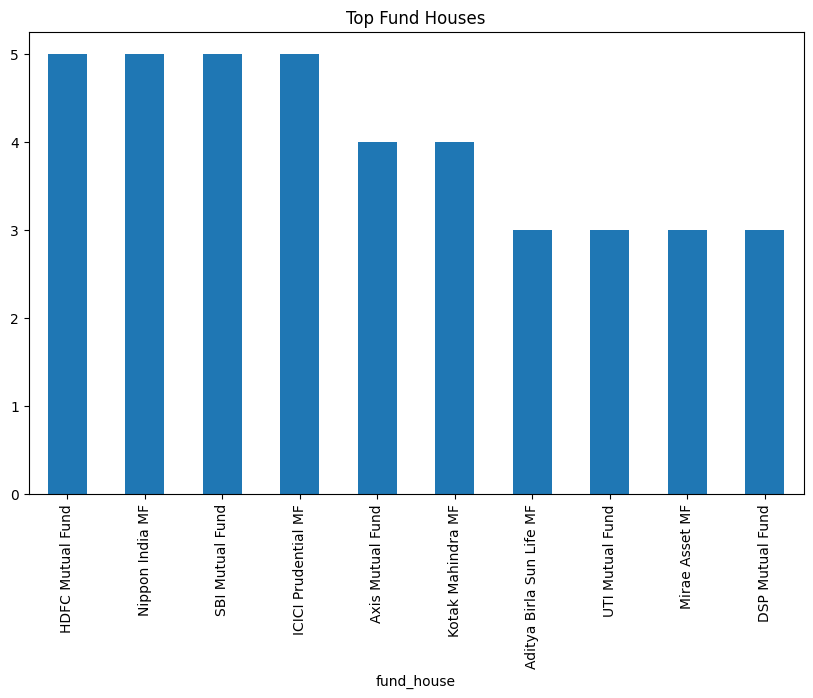

In [62]:
funds["fund_house"] \
    .value_counts() \
    .head(10) \
    .plot(
        kind="bar",
        figsize=(10,6)
    )

plt.title(
    "Top Fund Houses"
)

plt.show()

### Insight

A small number of fund houses control a significant share
of available schemes.

Chart 3 — NAV Distribution

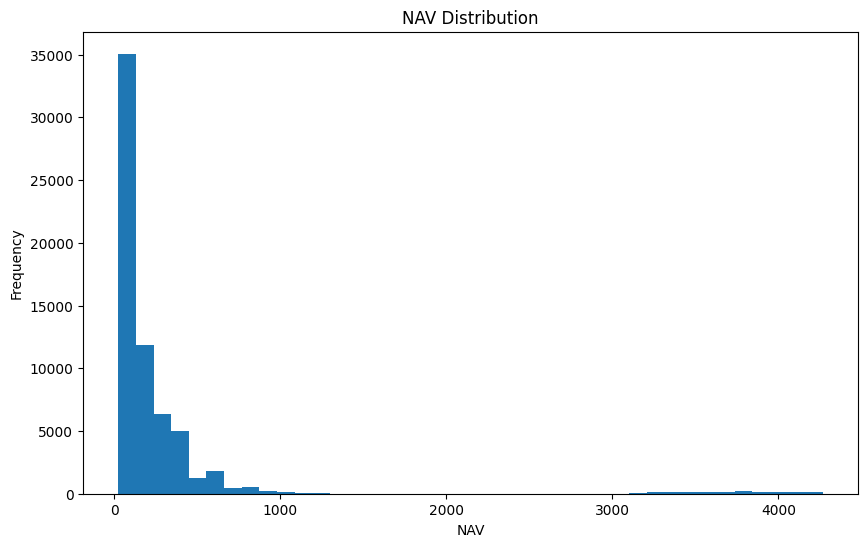

In [63]:
plt.figure(figsize=(10,6))

plt.hist(
    nav["nav"],
    bins=40
)

plt.title(
    "NAV Distribution"
)

plt.xlabel(
    "NAV"
)

plt.ylabel(
    "Frequency"
)

plt.show()

Chart 4 — Transaction State Analysis

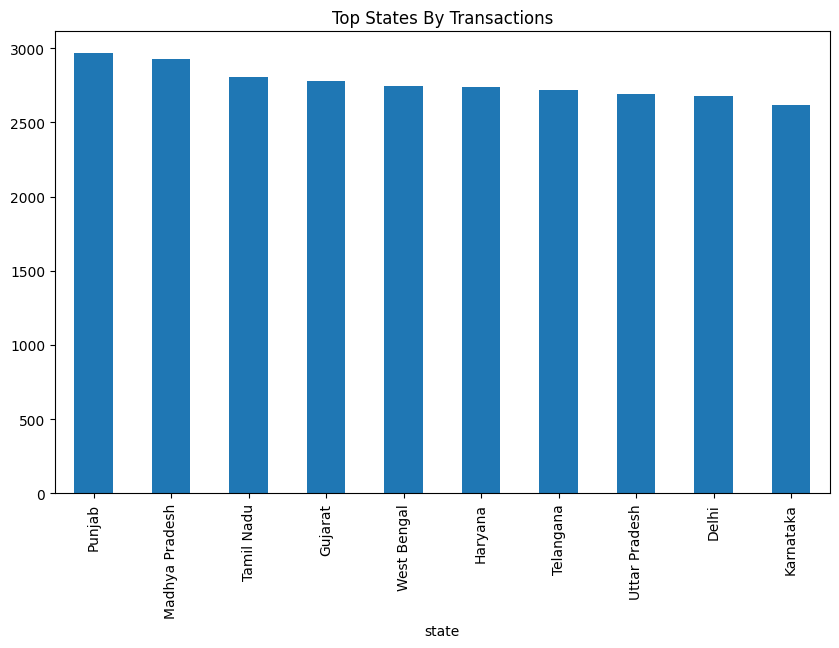

In [64]:
state_counts = (
    transactions["state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

state_counts.plot(
    kind="bar"
)

plt.title(
    "Top States By Transactions"
)

plt.show()

Chart 5 — Transaction Amount Distribution

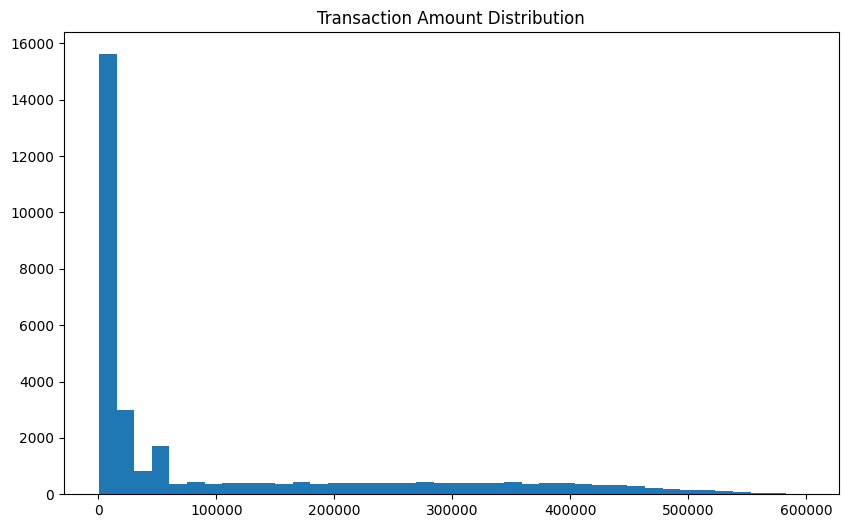

In [65]:
plt.figure(figsize=(10,6))

plt.hist(
    transactions["amount_inr"],
    bins=40
)

plt.title(
    "Transaction Amount Distribution"
)

plt.show()

Chart 6 — Sharpe Ratio Distribution

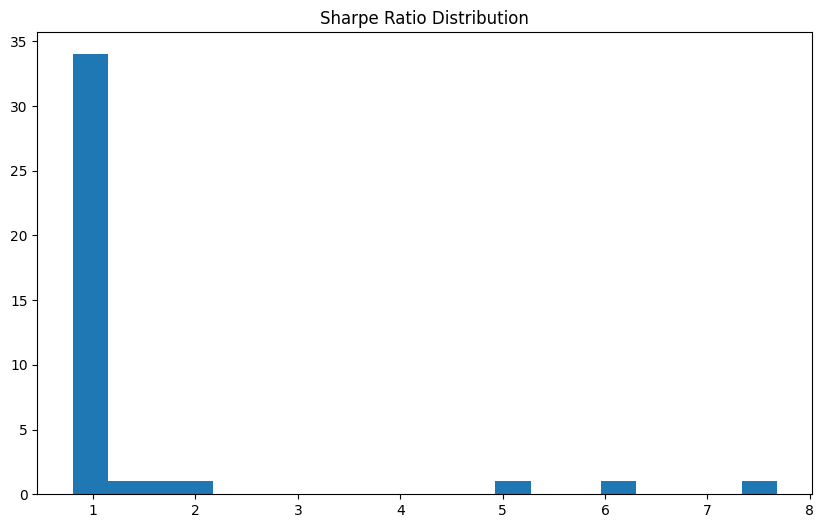

In [66]:
plt.figure(figsize=(10,6))

plt.hist(
    performance["sharpe_ratio"],
    bins=20
)

plt.title(
    "Sharpe Ratio Distribution"
)

plt.show()

Chart 7 — Top Sharpe Funds

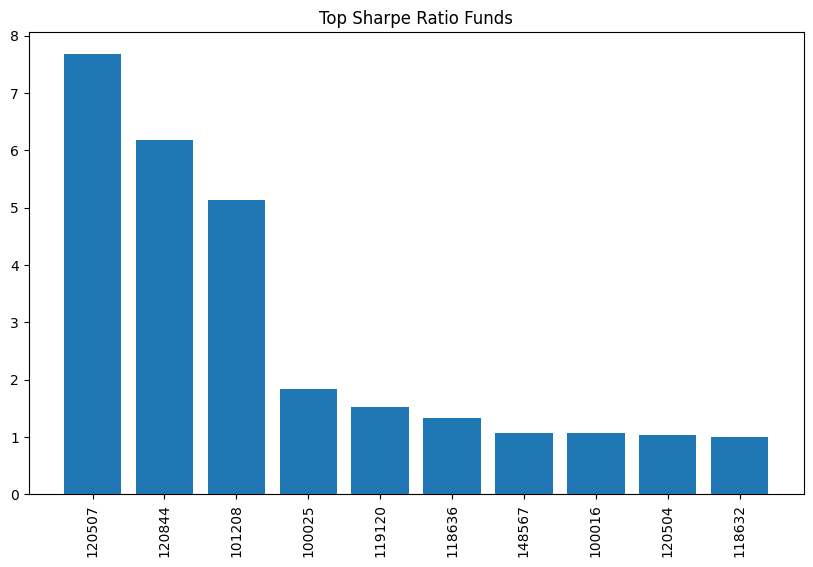

In [67]:
top_sharpe = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top_sharpe["amfi_code"].astype(str),
    top_sharpe["sharpe_ratio"]
)

plt.title(
    "Top Sharpe Ratio Funds"
)

plt.xticks(rotation=90)

plt.show()

Chart 8 — Return Distribution

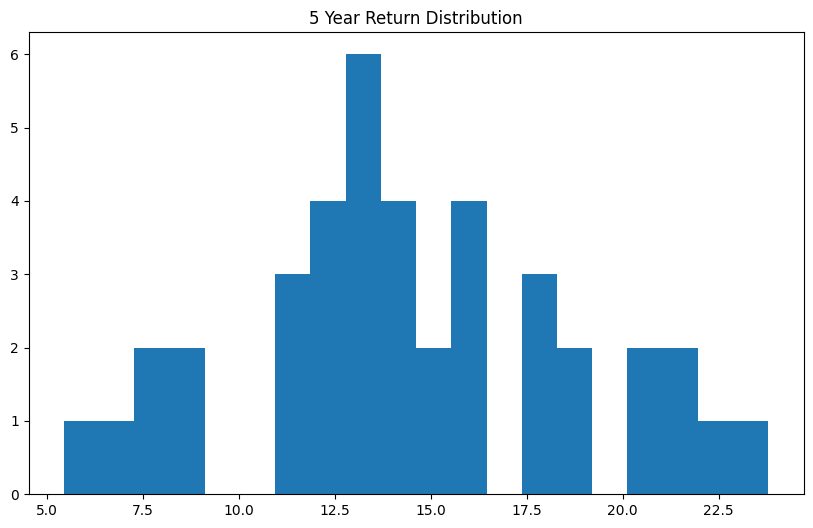

In [68]:
plt.figure(figsize=(10,6))

plt.hist(
    performance["return_5yr_pct"],
    bins=20
)

plt.title(
    "5 Year Return Distribution"
)

plt.show()

Chart 9 — Correlation Heatmap

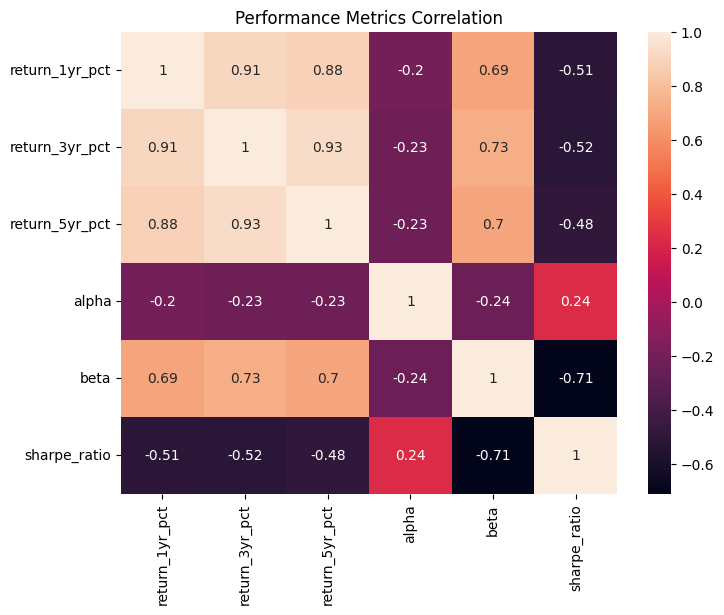

In [69]:
corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title(
    "Performance Metrics Correlation"
)

plt.show()

Chart 10 — Top Performing Funds

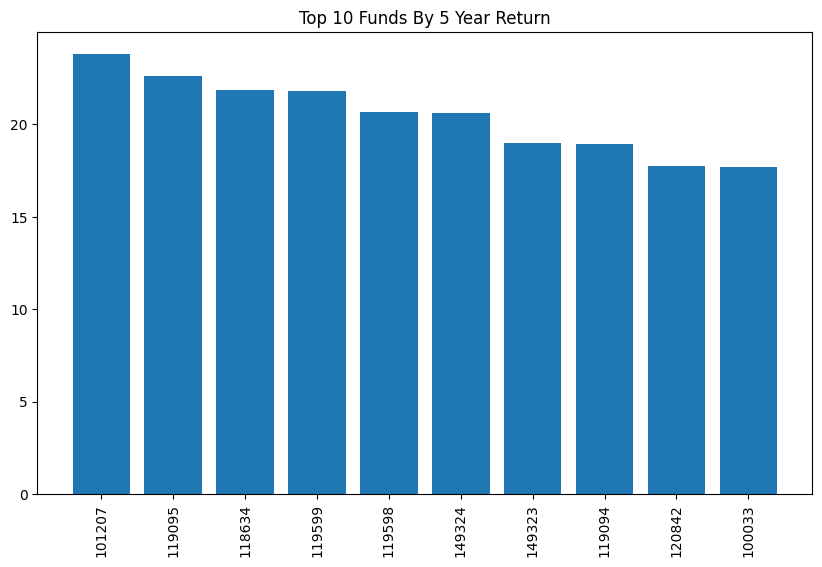

In [70]:
top_returns = (
    performance
    .sort_values(
        "return_5yr_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top_returns["amfi_code"].astype(str),
    top_returns["return_5yr_pct"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Funds By 5 Year Return"
)

plt.show()

In [71]:
engine.dispose()

print(
    "EDA Completed Successfully"
)

EDA Completed Successfully


In [72]:
# Executive Overview

summary = {
    "Total Funds": len(funds),
    "Total NAV Records": len(nav),
    "Total Transactions": len(transactions),
    "Total States": transactions["state"].nunique()
}

pd.DataFrame(summary.items(),
             columns=["Metric","Value"])

,Metric,Value
0,Total Funds,40
1,Total NAV Records,64320
2,Total Transactions,32778
3,Total States,12


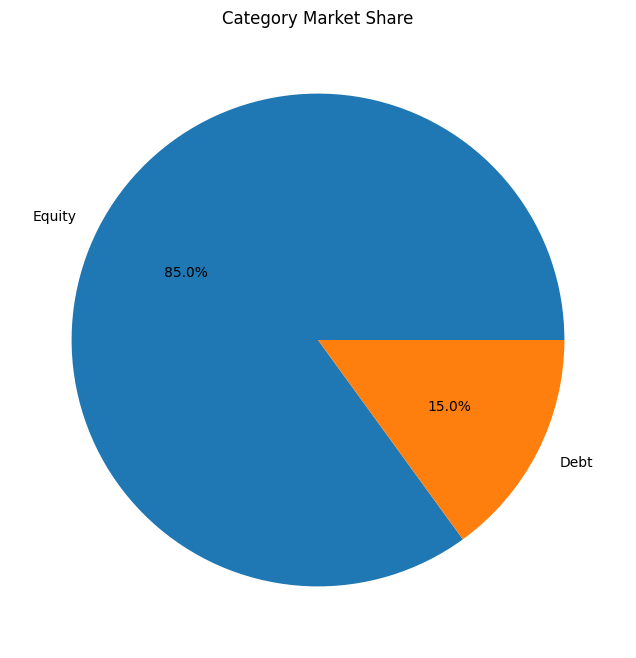

In [73]:
# Category Market Share

category_share = (
    funds["category"]
    .value_counts(normalize=True)
    * 100
)

category_share.head(10).plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Category Market Share")
plt.ylabel("")
plt.show()

Insight

Equity funds dominate market share, indicating strong investor preference for growth assets.

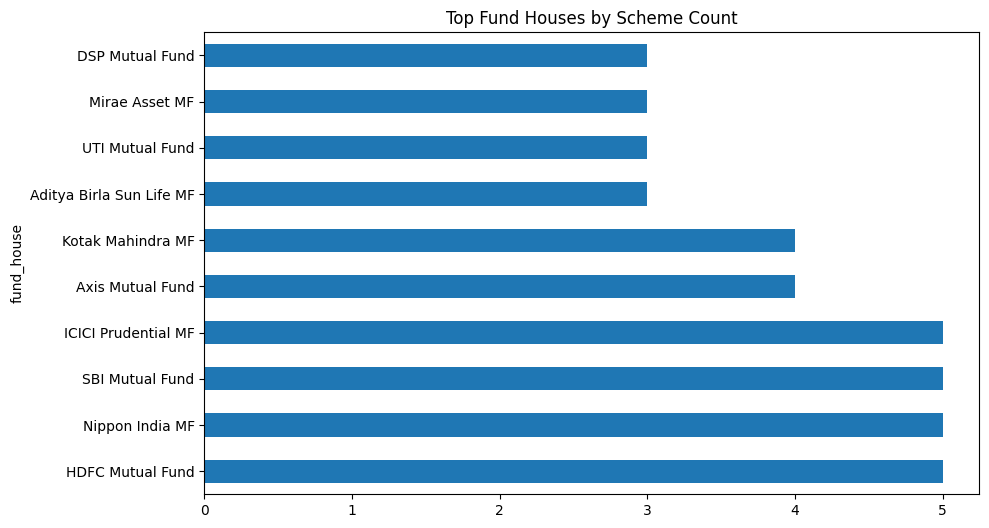

In [74]:
# Fund House Concentration Analysis

house_count = (
    funds["fund_house"]
    .value_counts()
    .head(15)
)

house_count.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Fund Houses by Scheme Count")
plt.show()

Insight

Market concentration suggests a few AMCs control most scheme offerings.

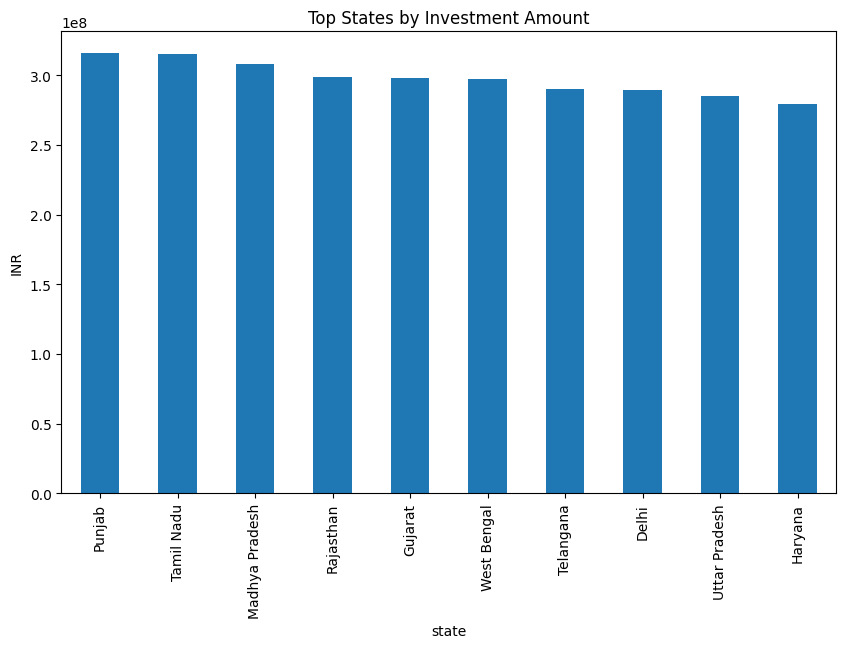

In [75]:
# Top States by Investment Volume

state_amt = (
    transactions
    .groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_amt.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Top States by Investment Amount"
)

plt.ylabel("INR")
plt.show()

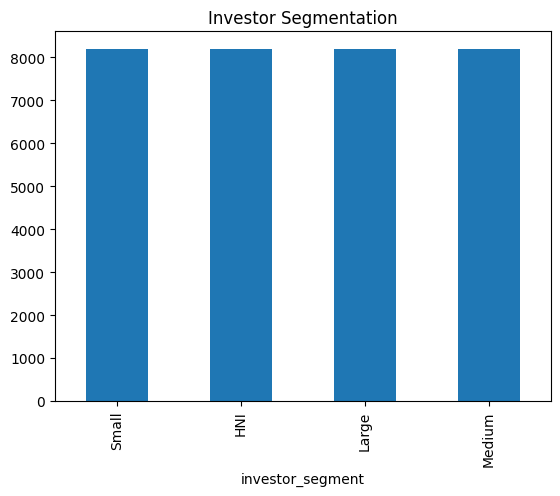

In [76]:
# Investor Segmentation

transactions["investor_segment"] = pd.qcut(
    transactions["amount_inr"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "HNI"
    ]
)

transactions[
    "investor_segment"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Investor Segmentation"
)

plt.show()

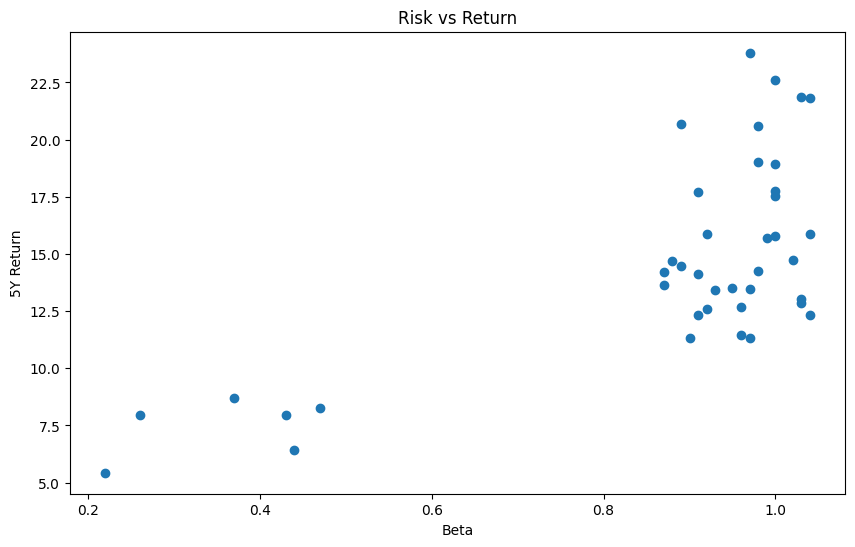

In [77]:
# Risk vs Return Analysis

plt.figure(figsize=(10,6))

plt.scatter(
    performance["beta"],
    performance["return_5yr_pct"]
)

plt.xlabel("Beta")
plt.ylabel("5Y Return")

plt.title(
    "Risk vs Return"
)

plt.show()

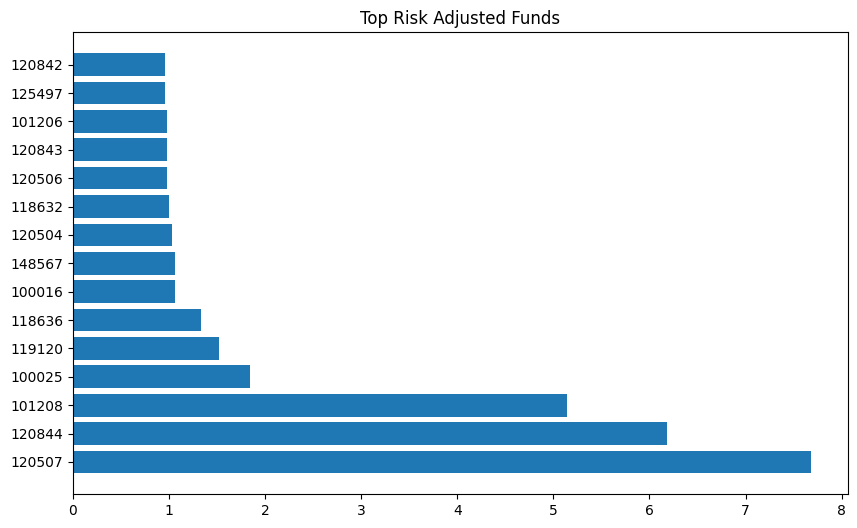

In [78]:
# Sharpe Ratio Ranking

top_sharpe = (
    performance
    .nlargest(
        15,
        "sharpe_ratio"
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top_sharpe["amfi_code"].astype(str),
    top_sharpe["sharpe_ratio"]
)

plt.title(
    "Top Risk Adjusted Funds"
)

plt.show()

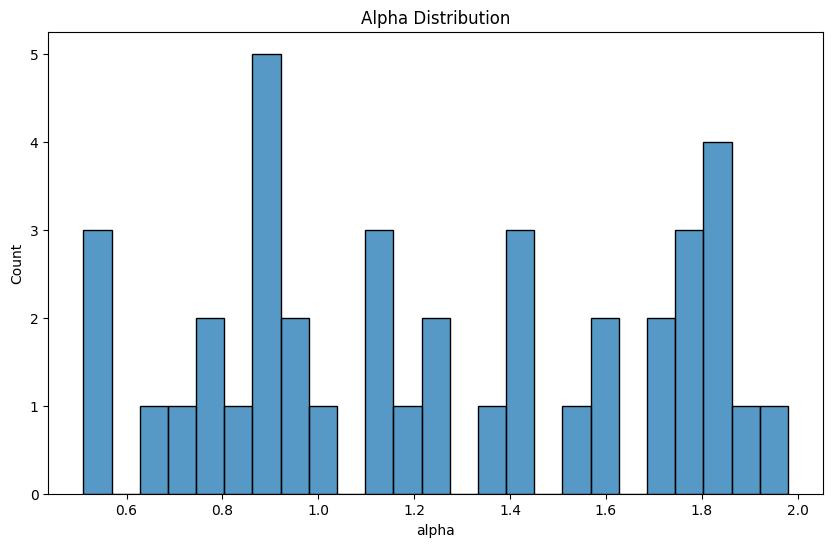

In [79]:
# Alpha Analysis

plt.figure(figsize=(10,6))

sns.histplot(
    performance["alpha"],
    bins=25
)

plt.title(
    "Alpha Distribution"
)

plt.show()

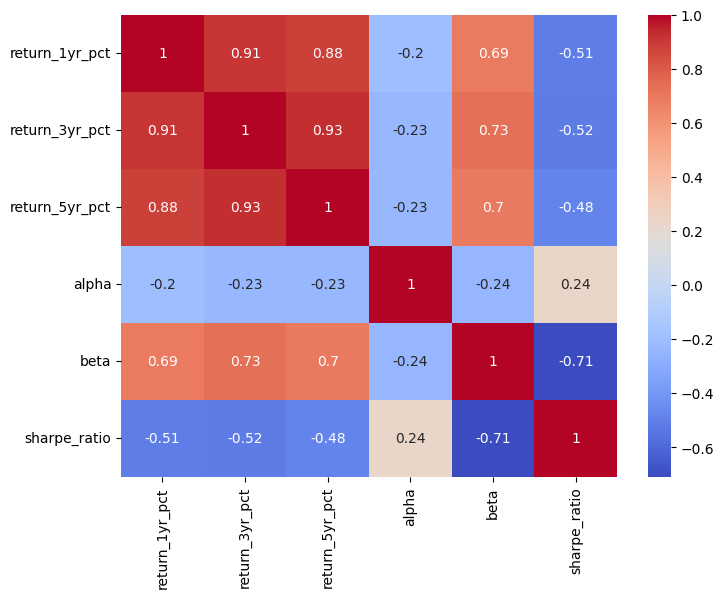

In [80]:
# Correlation Heatmap

corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

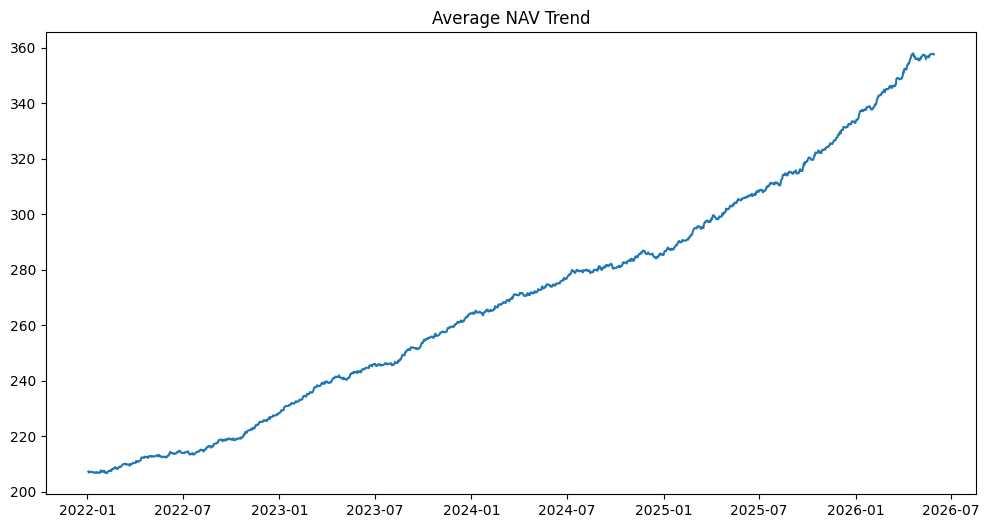

In [81]:
# NAV Trend Analysis

nav["nav_date"] = pd.to_datetime(
    nav["nav_date"]
)

nav_trend = (
    nav.groupby("nav_date")
    ["nav"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    nav_trend.index,
    nav_trend.values
)

plt.title(
    "Average NAV Trend"
)

plt.show()

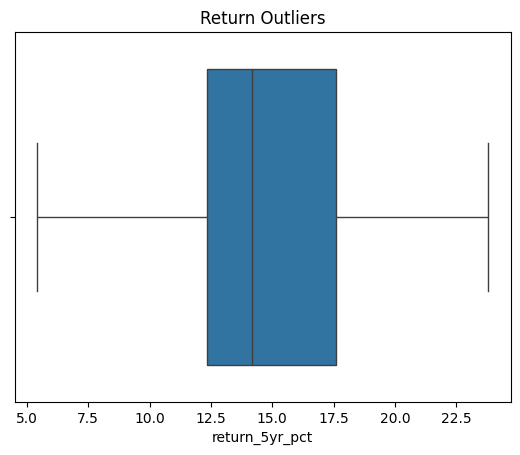

In [82]:
# Outlier Detection

sns.boxplot(
    x=performance["return_5yr_pct"]
)

plt.title(
    "Return Outliers"
)

plt.show()

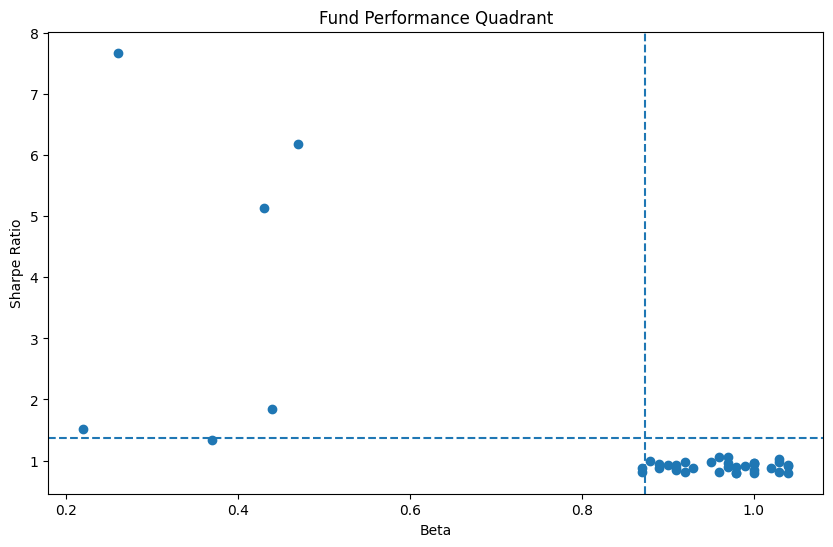

In [83]:
# Fund Performance Quadrant

plt.figure(figsize=(10,6))

plt.scatter(
    performance["beta"],
    performance["sharpe_ratio"]
)

plt.axvline(
    performance["beta"].mean(),
    linestyle="--"
)

plt.axhline(
    performance["sharpe_ratio"].mean(),
    linestyle="--"
)

plt.xlabel("Beta")
plt.ylabel("Sharpe Ratio")

plt.title(
    "Fund Performance Quadrant"
)

plt.show()